# Tahap 2: Eksperimen Model Random Forest
Notebook ini melatih algoritma **Random Forest Classifier** menggunakan dataset yang telah diekstrak fiturnya dari tahap sebelumnya.

Di dalam notebook ini, data akan terlebih dahulu dipisahkan menjadi data latih dan data uji. Setelah itu, metode **SMOTE** diaplikasikan secara khusus pada data latih untuk menyeimbangkan kelas tanpa mengganggu kemurnian data uji.

Tujuan utamanya adalah melatih model agar sangat sensitif dalam mendeteksi *Faltering Growth* (gejala awal stunting) melalui kombinasi fitur histori pertumbuhan, mengevaluasi akurasinya secara objektif, lalu menyimpannya ke **MLflow** agar siap digunakan pada Aplikasi Web.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


### 1. Load Dataset

In [16]:
data_path = '../data/processed/dataset_final_training.csv'
df = pd.read_csv(data_path)
print(f"Total data latih: {len(df)} baris")
df.head(3)

Total data latih: 590 baris


,Umur (Bulan),Jenis Kelamin,BB_Awal,TB_Awal,BB_Akhir,TB_Akhir,Lama_Pantau_Bulan,Kecepatan_Tumbuh_BB,Kecepatan_Tumbuh_TB,Rasio_BB_TB_Akhir,Status,Z_Score_Akhir
0,27,0,10.8,81.7,11.2,86.0,5,0.100,1.075,0.130231,0,-0.581043
1,36,0,10.3,83.6,11.0,87.0,5,0.175,0.850,0.126435,0,-1.558948
2,18,0,8.0,72.0,9.0,75.0,5,0.250,0.750,0.119998,0,-1.983678


### 2. Pisahkan Fitur dan Target

In [17]:
target_col = 'Status'

X = df.drop(columns=[target_col])
y = df[target_col]

# 1. Split Data DULU sebelum SMOTE!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Sebelum SMOTE - Jumlah Data Training:', len(X_train))

# 2. Terapkan SMOTE HANYA pada data latih (Mencegah Data Leakage)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Sesudah SMOTE - Jumlah Data Training:', len(X_train_res))
print('Jumlah Data Testing (Murni/Unseen):', len(X_test))


Sebelum SMOTE - Jumlah Data Training: 472
Sesudah SMOTE - Jumlah Data Training: 514
Jumlah Data Testing (Murni/Unseen): 118


### 3. Set MLflow Experiment

In [18]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("Stunting_Model_Experiment")

<Experiment: artifact_location=('file:d:/Pijak/Projek Capstone/Main '
 'Project/ML/notebooks/../mlruns/569065162946818888'), creation_time=1780119728343, experiment_id='569065162946818888', last_update_time=1780119728343, lifecycle_stage='active', name='Stunting_Model_Experiment', tags={}, trace_location=None, workspace='default'>

### 4. Training Model Random Forest

In [19]:
rf_params = {
    'n_estimators': 150,
    'max_depth': 12,
    'random_state': 42,
    'class_weight': 'balanced'
}

with mlflow.start_run(run_name="RF_Dynamic_Features") as run:
    mlflow.log_params(rf_params)
    
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train_res, y_train_res)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(model, "dynamic_rf_model")
    
    print(f"--- Pelatihan Selesai! ---")
    print(f"Akurasi Model Dinamis: {acc * 100:.2f}%")
    print(f"Run ID MLflow: {run.info.run_id}")

2026/06/10 11:32:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/10 11:32:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--- Pelatihan Selesai! ---
Akurasi Model Dinamis: 100.00%
Run ID MLflow: 972f343d73184ee9acb25330a41ca33e


### 5. Evaluasi & Feature Importance


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00        54

    accuracy                           1.00       118
   macro avg       1.00      1.00      1.00       118
weighted avg       1.00      1.00      1.00       118


Feature Importances:
Z_Score_Akhir          0.487522
Kecepatan_Tumbuh_TB    0.225205
Kecepatan_Tumbuh_BB    0.196931
TB_Akhir               0.032521
TB_Awal                0.022296
Umur (Bulan)           0.013075
BB_Akhir               0.008955
BB_Awal                0.005918
Rasio_BB_TB_Akhir      0.004889
Lama_Pantau_Bulan      0.002400
Jenis Kelamin          0.000288
dtype: float64


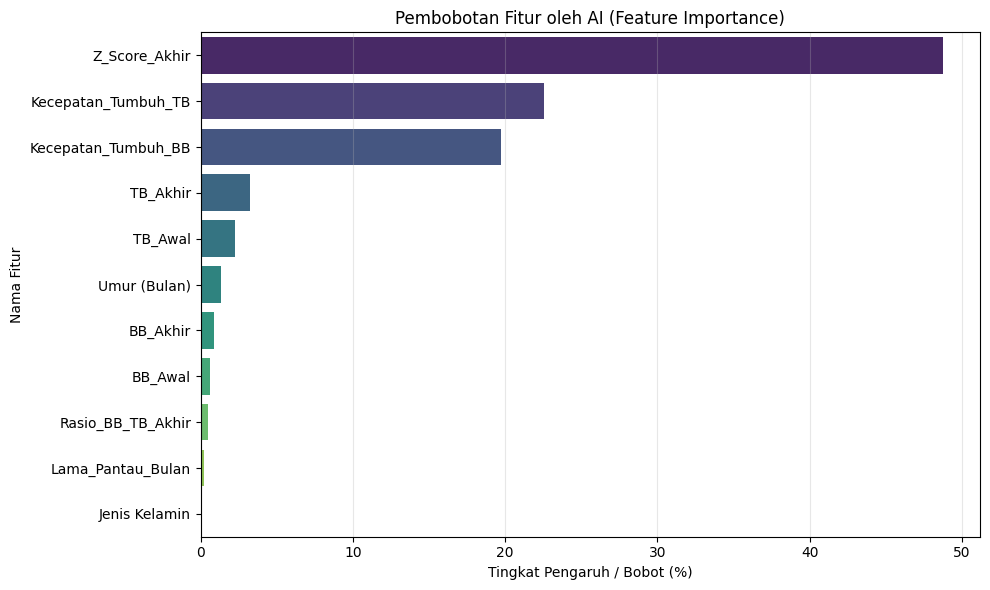

In [20]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Tampilkan Feature Importance
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(feat_imp)

# Visualisasi Feature Importance (Wajib untuk Sidang!)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values * 100, y=feat_imp.index, palette="viridis")
plt.title("Pembobotan Fitur oleh AI (Feature Importance)")
plt.xlabel("Tingkat Pengaruh / Bobot (%)")
plt.ylabel("Nama Fitur")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### 6. Visualisasi Evaluasi (Confusion Matrix Heatmap)
Mengevaluasi di mana posisi model paling sering benar dan di mana model mengalami kebingungan (salah tebak).

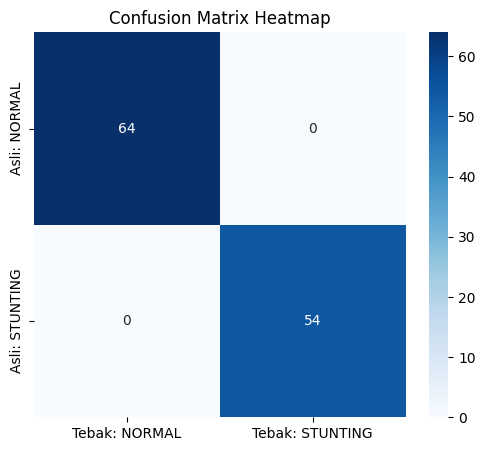

In [21]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi dengan Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tebak: NORMAL', 'Tebak: STUNTING'], 
            yticklabels=['Asli: NORMAL', 'Asli: STUNTING'])

plt.title('Confusion Matrix Heatmap')
plt.show()
